# Analisis Exploratorio Continuacion
## Mario Alejandro Castro Lerma

Continuacion de EDA a partir del dataset rick_eda_imput.csv generado por Esthefania en 2.1-eot-EDA_PCA.ipynb

---

### Analisis rapido

In [36]:
import pandas as pd
import numpy as np

In [37]:
df = pd.read_csv("../data/interim/rick_eda_imput.csv")
# df = pd.read_csv("../data/interim/rick_hist.csv")

In [38]:
df.head()

,ide_id,ide_sex,ide_eda_ano,des_cal,ide_col,des_jur_res,des_mpo_res,cve_loc_res,des_loc_res,ide_cp,...,dias_estudio,demora_pac,demora_pac_fiebre,demora_pac_signos_alarma,fec_ini_estudio_corr,fec_fin_estudio_corr,fec_sol_aten_corr,fec_ini_signos_alarma_corr,fec_ini_signos_sint_corr,fec_ini_fiebre_corr
0,928424,1,39,CALLE,PASEOS DEL PEDREGAL Fraccionamiento,HERMOSILLO,HERMOSILLO,289,HERMOSILLO,83118.0,...,7.0,2,2.0,1.0,False,False,False,False,False,False
1,928745,2,8,CALLE,SAN RAFAEL Colonia,SAN LUIS RIO COLORADO,PUERTO PEÑASCO,1,PUERTO PEÑASCO,83557.0,...,NaN,1,1.0,NaN,False,False,False,False,False,False
2,928768,2,2,CALLE,EL BOSQUE (CALLE QUINCE) Ejido,CAJEME,CAJEME,365,QUETCHEHUECA,85207.0,...,0.0,3,3.0,NaN,False,False,False,False,False,False
3,929029,1,9,PRIVADA,PUERTO PEÑASCO CENTRO Colonia,SAN LUIS RIO COLORADO,PUERTO PEÑASCO,1,PUERTO PEÑASCO,83550.0,...,NaN,3,2.0,NaN,False,False,False,False,False,False
4,929184,2,13,CALLE,PALO BLANCO Congregación,NAVOJOA,NAVOJOA,124,TESIA,85235.0,...,24.0,8,8.0,NaN,False,False,False,False,False,False


Por nota de Esthefania eliminare _corr, _imput, _uni_trat y otras columnas

In [39]:
cols_to_remove = [col for col in df.columns if col.endswith(('_corr', '_imput', '_uni_trat'))]
cols_to_remove += ['ide_cp', 'des_diag_final', 'compromiso_organos'] 
print(f"Columns to remove: {cols_to_remove}")
df = df.drop(columns=cols_to_remove)

Columns to remove: ['des_jur_uni_trat', 'des_mpo_uni_trat', 'des_ins_uni_trat', 'des_cual_lengua_imput', 'otros_especifique_imput', 'contacto_otr_imput', 'otro_sintoma_imput', 'otr_serv_atencion_imput', 'temperatura_imput', 'fec_ini_estudio_corr', 'fec_fin_estudio_corr', 'fec_sol_aten_corr', 'fec_ini_signos_alarma_corr', 'fec_ini_signos_sint_corr', 'fec_ini_fiebre_corr', 'ide_cp', 'des_diag_final', 'compromiso_organos']


In [40]:
df.shape

(2631, 172)

Columnas con vacios:

In [41]:
for col in df.columns:
    if df[col].isna().any():
        print(f"{col}: {df[col].isna().sum()}")
        

fec_ini_estudio: 2
fec_fin_estudio: 1265
fec_ini_fiebre: 80
fec_ini_signos_alarma: 2211
fec_ingreso: 1153
cve_uni_med_tratante: 810
des_unidad_tratante: 810
cve_diag_hospit: 1325
fec_egreso: 1549
fec_defuncion: 2291
fecha_toma_rickett_ser1: 1382
fecha_recep_rickett_ser1: 1610
fecha_resultado_rickett_ser1: 1640
rickett_resultado_ser1: 191
fecha_toma_rickett_sangre: 300
fecha_recep_rickett_sangre: 381
mstra_rech_ricket_sangre: 191
motiv_rech_ricket_sangre: 191
ricket_cq_lesp: 191
ricket_cq: 191
res_final_ricket_inmuno: 191
res_final_ricket_rtpcr: 191
fecha_resultado_rickett_rtpcr: 406
ricket_especie_rtpcr: 191
fec_ini_trat_ricket: 655
fec_fin_trat_ricket: 1806
des_ins_uni_trat_norm: 704
tiempo_res_hosp: 1
dias_estudio: 1263
demora_pac_fiebre: 80
demora_pac_signos_alarma: 2211


Dropeare las columnas con mas de 80% de faltantes

In [42]:
# Percentage threshold
threshold = 0.80
cols_to_drop = df.columns[df.isnull().mean() > threshold]

# Drop them
df = df.drop(columns=cols_to_drop)

# Optional: see which columns were removed
print("Dropped columns:")
print(list(cols_to_drop))

Dropped columns:
['fec_ini_signos_alarma', 'fec_defuncion', 'demora_pac_signos_alarma']


In [43]:
df.shape

(2631, 169)

---

### Separando el dataset en 2, uno para la prediccion de rickettsia y otro para predecir la letalidad

In [44]:
easy_access_cols = [

    # Demographics
    "ide_sex",
    "ide_eda_ano",
    "es_indigena",

    # Exposure
    "contacto_garrapata",
    "contacto_otr",
    "agua_potable",
    "eliminacion_basura",

    # Symptoms / signs
    "temperatura",
    "cefalea",
    "mialgias",
    "artralgias",
    "exantema",
    "nauseas",
    "vomito",
    "petequias",
    "dolor_abdominal_intenso",
    "letargo",
    "irritabilidad",
    "taquicardia",
    "fotofobia",
    "diarrea",
    "conjuntivitis",
    "tos",
    "faringitis",
    "ictericia",
    "convulsiones",
    "somolencia",
    "adinamia",
    "astenia",
    "cefalea_frontal",
    "perdida_peso",
    "escalofrios",
    "diaforesis",
    "anorexia",

    # Comorbidities
    "diabetes",
    "hipertension",
    "enf_ulcero_peptica",
    "enf_renal",
    "inmunosupresion",
    "cirrosis_hepatica",
    "embarazo",
    "sem_gest",

    # Temporal progression
    "demora_pac",
    "demora_pac_fiebre",
]

target_col = "estatus_caso"

prediction_df = df[easy_access_cols + [target_col]]

In [45]:
prediction_df.head() 

,ide_sex,ide_eda_ano,es_indigena,contacto_garrapata,contacto_otr,agua_potable,eliminacion_basura,temperatura,cefalea,mialgias,...,hipertension,enf_ulcero_peptica,enf_renal,inmunosupresion,cirrosis_hepatica,embarazo,sem_gest,demora_pac,demora_pac_fiebre,estatus_caso
0,1,39,2,1,Se ignora,2,2,39.0,2,1,...,0,0,0,0,0,0,0,2,2.0,2
1,2,8,2,1,Se ignora,1,2,39.0,1,1,...,0,0,0,0,0,0,0,1,1.0,3
2,2,2,2,0,Se ignora,1,1,39.0,1,1,...,0,0,0,0,0,0,0,3,3.0,1
3,1,9,2,1,Se ignora,1,1,39.0,1,1,...,0,0,0,0,0,0,0,3,2.0,3
4,2,13,2,1,Se ignora,1,1,39.0,1,1,...,0,0,0,0,0,0,0,8,8.0,2


In [46]:
for col in prediction_df.columns:
    if prediction_df[col].isna().any():
        print(f"{col}: {prediction_df[col].isna().sum()}")

demora_pac_fiebre: 80


In [47]:
prediction_df['demora_pac_fiebre'].describe()

count    2551.000000
mean        2.914543
std         2.735631
min        -3.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        63.000000
Name: demora_pac_fiebre, dtype: float64

Como no sabemos la demora en esos 80 pacientes, he decidido utilizar la media.

In [48]:
prediction_df.fillna(value={'demora_pac_fiebre': prediction_df['demora_pac_fiebre'].mean()}, inplace=True)

,ide_sex,ide_eda_ano,es_indigena,contacto_garrapata,contacto_otr,agua_potable,eliminacion_basura,temperatura,cefalea,mialgias,...,hipertension,enf_ulcero_peptica,enf_renal,inmunosupresion,cirrosis_hepatica,embarazo,sem_gest,demora_pac,demora_pac_fiebre,estatus_caso
0,1,39,2,1,Se ignora,2,2,39.0,2,1,...,0,0,0,0,0,0,0,2,2.0,2
1,2,8,2,1,Se ignora,1,2,39.0,1,1,...,0,0,0,0,0,0,0,1,1.0,3
2,2,2,2,0,Se ignora,1,1,39.0,1,1,...,0,0,0,0,0,0,0,3,3.0,1
3,1,9,2,1,Se ignora,1,1,39.0,1,1,...,0,0,0,0,0,0,0,3,2.0,3
4,2,13,2,1,Se ignora,1,1,39.0,1,1,...,0,0,0,0,0,0,0,8,8.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2626,2,20,2,1,Se ignora,1,2,39.0,1,1,...,0,0,0,0,0,0,0,2,2.0,2
2627,2,24,2,1,Se ignora,1,1,39.0,1,2,...,0,0,0,0,0,0,0,3,3.0,3
2628,2,20,2,1,Se ignora,1,1,39.0,1,1,...,0,0,0,0,0,0,0,8,8.0,2
2629,1,1,2,1,Se ignora,0,0,38.0,1,2,...,0,0,0,0,0,0,0,2,2.0,3


In [49]:
for col in prediction_df.columns:
    if prediction_df[col].isna().any():
        print(f"{col}: {prediction_df[col].isna().sum()}")

Revisando la columna con str:

In [50]:
prediction_df['contacto_otr'].value_counts()

contacto_otr
Se ignora                    2317
Perros                        229
Perros con ectoparásitos       20
Perros y gatos                 19
Sin contacto                   14
Perros con garrapatas           9
Roedores                        4
Pulgas                          3
Gatos                           3
Garrapatas                      3
Zoonosis                        2
Insectos no especificados       2
Exposición ambiental            2
Perros y caballos               1
Conejos                         1
Otros animales                  1
Arañas                          1
Name: count, dtype: int64

In [51]:
prediction_df['contacto_otr'] = prediction_df['contacto_otr'].str.lower()

Este dataframe es el que utilizarmos a partir de aqui y ya se encuentra limpio, asi que lo guardare en processed

In [62]:
prediction_df.to_csv('../data/processed/rickettsia_for_predictions.csv', index = False)

### Aplicando modelo no supervisado

In [52]:
model_df = prediction_df.copy()
X = model_df.drop(columns=["estatus_caso"])
y = model_df["estatus_caso"]

trabajando con categoricas:

In [53]:
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()

for col in X_encoded.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(
        X_encoded[col].astype(str)
    )

C:\Users\MasterHDXD\AppData\Local\Temp\ipykernel_16828\1844065949.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_encoded.select_dtypes(include="object").columns:


escalando valores numericos:

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)

#### Usando UMAP

In [55]:
import umap

umap_model = umap.UMAP(
    n_neighbors=20,
    min_dist=0.05,
    metric="euclidean",
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

d:\MasterHDXD\Escuela\Maestria\MachineLearning\Rickettsia\rickettsia_sonora\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#### Usando hdbscan

In [56]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=40,
    min_samples=10
)

clusters = clusterer.fit_predict(X_umap)

In [57]:
model_df["cluster"] = clusters

pd.crosstab(
    model_df["cluster"],
    model_df["estatus_caso"],
    normalize="index"
)

estatus_caso,1,2,3
cluster,,,
-1,0.177994,0.216828,0.605178
0,0.275000,0.062500,0.662500
1,0.088608,0.189873,0.721519
2,0.116667,0.216667,0.666667
3,0.173913,0.108696,0.717391
4,0.227778,0.100000,0.672222
5,0.166667,0.187500,0.645833
6,0.144828,0.144828,0.710345
7,0.113514,0.178378,0.708108


Visualizar los datos

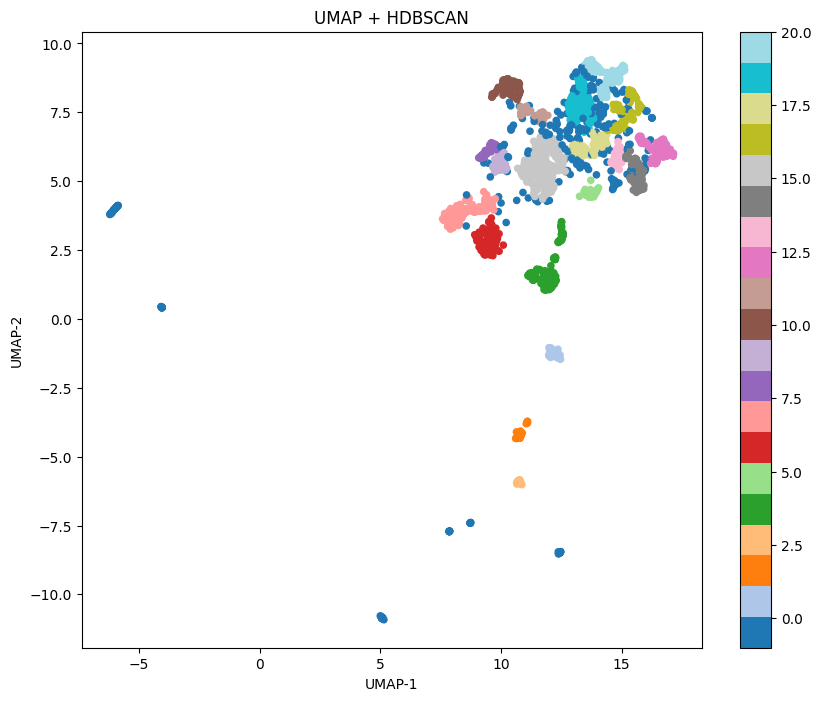

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=clusters,
    cmap="tab20",
    s=20
)

plt.colorbar(scatter)

plt.title("UMAP + HDBSCAN")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.show()

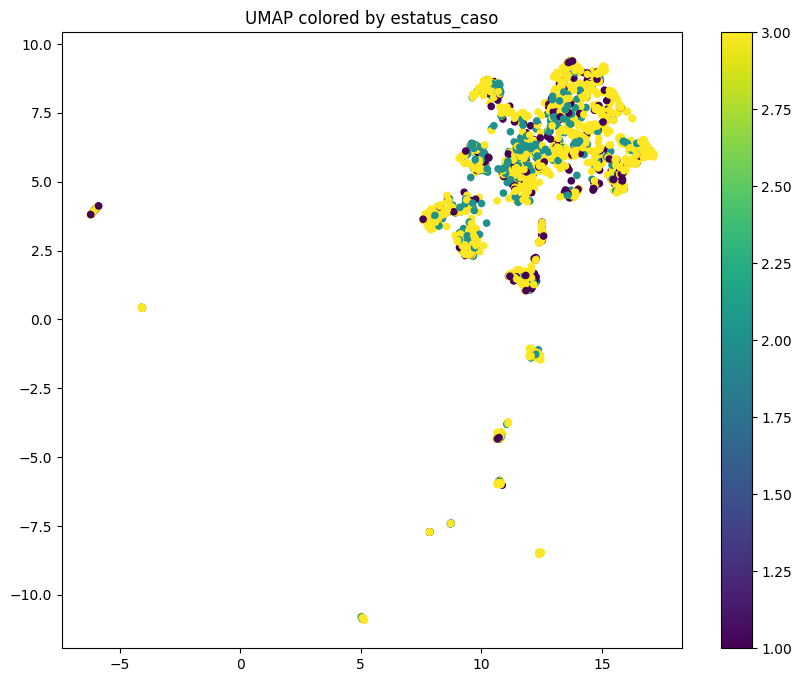

In [59]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=y,
    cmap="viridis",
    s=20
)

plt.colorbar(scatter)

plt.title("UMAP colored by estatus_caso")

plt.show()

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.03,
    random_state=42
)

outliers = iso.fit_predict(X_scaled)

model_df["outlier"] = outliers

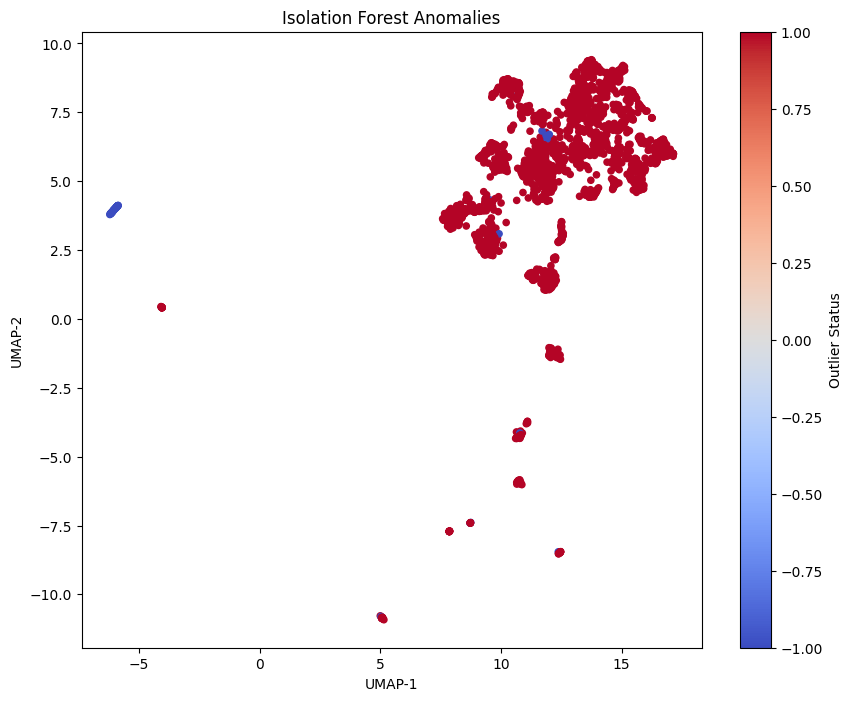

In [63]:

plt.figure(figsize=(10, 8))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=model_df["outlier"],
    cmap="coolwarm",
    s=20
)

plt.title("Isolation Forest Anomalies")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.colorbar(label="Outlier Status")

plt.show()

In [64]:
pd.crosstab(
    model_df["outlier"],
    model_df["estatus_caso"],
    normalize="index"
)

estatus_caso,1,2,3
outlier,,,
-1,0.240506,0.189873,0.569620
1,0.138715,0.185737,0.675549


In [65]:
anomalies_df = model_df[
    model_df["outlier"] == -1
]

anomalies_df.head()

,ide_sex,ide_eda_ano,es_indigena,contacto_garrapata,contacto_otr,agua_potable,eliminacion_basura,temperatura,cefalea,mialgias,...,enf_renal,inmunosupresion,cirrosis_hepatica,embarazo,sem_gest,demora_pac,demora_pac_fiebre,estatus_caso,cluster,outlier
20,1,0,2,1,se ignora,1,1,38.0,2,2,...,0,0,0,0,0,1,1.000000,3,0,-1
31,2,64,2,0,se ignora,0,0,39.0,0,0,...,0,0,0,0,0,4,2.914543,1,0,-1
92,1,32,2,1,se ignora,0,2,39.0,1,1,...,0,0,0,0,0,7,7.000000,2,15,-1
118,2,14,2,1,se ignora,1,1,38.0,2,1,...,0,0,0,0,0,5,2.000000,3,0,-1
123,1,50,2,1,se ignora,1,1,40.0,1,1,...,0,0,0,0,0,1,1.000000,2,0,-1


In [66]:
symptom_cols = [
    "cefalea",
    "mialgias",
    "exantema",
    "fotofobia",
    "convulsiones",
]

anomalies_df[symptom_cols].mean()

cefalea         1.050633
mialgias        1.240506
exantema        1.544304
fotofobia       0.506329
convulsiones    0.481013
dtype: float64